Chart Analysis
Use Python to retrieve stock market data and analyze price changes.
1. Fetch both daily and hourly stock market data using a suitable API.
Visualize the data in several types of plots.
2. Plot long-term stock data over multiple years.
Create an interactive graph that allows the user to view different time ranges.
3. Start with Apple (AAPL) and plot its stock chart using daily data over several years.
4. Add moving averages to the stock charts, such as:
○ SMA20 and SMA50, or
○ SMA50 and SMA150
These should be overlaid on the main stock price chart.
5. Create a table for five stocks. Use default examples such as FAANG stocks plus
NVIDIA, but allow the user to change them.
For each stock, calculate the historical probability that the next day is positive if the
current day changes by:
+2%, +3%, +4%, +5%, and +6%.
Example: if Apple rises 5% today, what is the historical probability that the next day
closes positive?
Use the last 2 years of historical data.
6. Repeat the same analysis for negative daily moves, such as:
-2%, -3%, -4%, and -5%.
7. Repeat both of the above analyses again using 5 years of historical data.
8. Create a comparison table for the five selected stocks.
Include a simple correlation / collinearity analysis between them.
9. Plot a comparison chart for two to five stocks using daily data for one year.
Example: compare Apple and Amazon.
Normalize or rescale prices if needed so they can be compared clearly.
10. Create another table for the same five stocks showing the probability that the next day
is positive after:
● 2 consecutive positive days
● 3 consecutive positive days
● 4 consecutive positive days
● 5 consecutive positive days
● 6 consecutive positive days
11. Repeat the same analysis for consecutive negative days.
12. Screen all Nasdaq and NYSE stocks and identify the top 10 trending stocks, ranked
by daily percentage change.
13. Repeat the screening, but only include stocks with a market capitalization of $5 billion
or more.
This may require obtaining market cap data from an API or web scraping source.

I will be using the Massive API, formerly polygon.io. Massive obtains its data from an aggregate of all major US stock exchanges. The plan I am selecting provides 5 years of historical data.

In this section, I downloaded 5 years of daily data for over 5000 common stocks.

With raw daily data downloaded, I then reduced it to contain only stocks with an average of 30000 transactions, and with very few missing days.

# 1. Downloading Data - AKA the beast
This function downloaded over 5000 stocks. I never planned on using them all, but it is useful to have them all in front of me for decision-making. I commented out this entire block because it took about an hour to run, and my API access will be gone soon anyway.

Some storage paths may be different from the final result. Changing the code doesn't matter since I probably won't run this code again anyway, but if I think of it I will try to make it match anyway for the sake of cleanliness.

In [3]:
%%time

import requests
import pandas as pd
from pathlib import Path
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta
import time


# -------------------------
# SETTINGS
# -------------------------

API_KEY_PATH = "api_keys/massive.txt"
SAVE_FOLDER = "raw_daily_data"
COMBINED_OUTPUT_FILE = "raw_daily_data/combined_daily_data.csv"

YEARS = 5
SAFETY_DAYS = 1
RATE_LIMIT_SECONDS = 0.2

# Choose one of these:
# common_stocks_plus_fb accounts for the FB/META problem 
# while otherwise maintaining stringency with active stocks

FILTER_PROFILE = "common_stocks_plus_fb"
# FILTER_PROFILE = "common_stocks"
# FILTER_PROFILE = "common_stocks_and_adrs"
# FILTER_PROFILE = "etfs"
# FILTER_PROFILE = "everything_major_exchanges"
# FILTER_PROFILE = "manual_test"


MANUAL_TICKERS = [
    "AAPL", "MSFT", "NVDA", "GOOGL", "AMZN",
    "TSLA", "NFLX", "JPM", "WMT", "SPY"
]


FILTER_PROFILES = {
    "common_stocks": {
        "types": ["CS"],
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "common_stocks_and_adrs": {
        "types": ["CS", "ADR"],
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "etfs": {
        "types": ["ETF"],
        "exchanges": ["ARCX", "XNAS", "XNYS"],
        "active": True,
    },
    "everything_major_exchanges": {
        "types": None,
        "exchanges": ["XNYS", "XNAS"],
        "active": True,
    },
    "manual_test": {
        "manual_tickers": MANUAL_TICKERS,
    },
}


FILTER_PROFILES["common_stocks_plus_fb"] = {
    "types": ["CS"],
    "exchanges": ["XNYS", "XNAS"],
    "active": True,
    "include_tickers": ["FB"]
}


# -------------------------
# API HELPERS
# -------------------------

def load_api_key(filepath=API_KEY_PATH):
    return Path(filepath).read_text(encoding="utf-8").strip()


def get_all_pages(url, params=None):
    all_results = []

    api_key = params.get("apiKey") if params else None

    while url:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if data.get("status") == "NOT_AUTHORIZED":
            raise PermissionError(data.get("message", "Not authorized for this request."))

        all_results.extend(data.get("results", []))

        url = data.get("next_url")

        if url and api_key and "apiKey=" not in url:
            separator = "&" if "?" in url else "?"
            url = f"{url}{separator}apiKey={api_key}"

        params = None

    return all_results


# -------------------------
# TICKER UNIVERSE
# -------------------------

def get_massive_ticker_reference(api_key_path=API_KEY_PATH):
    api_key = load_api_key(api_key_path)

    url = "https://api.massive.com/v3/reference/tickers"

    params = {
        "market": "stocks",
        "active": "true",
        "sort": "ticker",
        "limit": 1000,
        "apiKey": api_key,
    }

    results = get_all_pages(url, params)

    if not results:
        raise ValueError("No ticker reference data returned.")

    return pd.DataFrame(results)


def apply_ticker_filter(df_tickers, profile_name):
    profile = FILTER_PROFILES[profile_name]

    if "manual_tickers" in profile:
        tickers = profile["manual_tickers"]
        return df_tickers[df_tickers["ticker"].isin(tickers)].copy(), tickers

    filtered = df_tickers.copy()

    if profile.get("active") is not None:
        filtered = filtered[filtered["active"] == profile["active"]]

    if profile.get("types") is not None:
        filtered = filtered[filtered["type"].isin(profile["types"])]

    if profile.get("exchanges") is not None:
        filtered = filtered[filtered["primary_exchange"].isin(profile["exchanges"])]

    filtered = filtered.sort_values("ticker").reset_index(drop=True)

    tickers = filtered["ticker"].tolist()

    return filtered, tickers


# -------------------------
# DAILY BAR FETCHING
# -------------------------

def get_massive_daily_bars(
    ticker,
    api_key_path=API_KEY_PATH,
    years=YEARS,
    safety_days=SAFETY_DAYS,
    adjusted=True,
    sort="asc"
):
    api_key = load_api_key(api_key_path)

    today = date.today()
    start_date = today - relativedelta(years=years) + timedelta(days=safety_days)

    url = (
        f"https://api.massive.com/v2/aggs/ticker/"
        f"{ticker}/range/1/day/{start_date.isoformat()}/{today.isoformat()}"
    )

    params = {
        "adjusted": str(adjusted).lower(),
        "sort": sort,
        "limit": 50000,
        "apiKey": api_key,
    }

    results = get_all_pages(url, params)

    if not results:
        raise ValueError(f"No data returned for {ticker}.")

    df = pd.DataFrame(results).rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "transactions",
    })

    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms").dt.date
    df["ticker"] = ticker

    preferred_order = [
        "timestamp", "ticker", "open", "high", "low", "close",
        "volume", "vwap", "transactions"
    ]

    return df[[col for col in preferred_order if col in df.columns]]


def fetch_save_and_return_ticker(
    ticker,
    save_folder=SAVE_FOLDER,
    overwrite=False
):
    Path(save_folder).mkdir(exist_ok=True)

    filename = Path(save_folder) / f"daily_{ticker.lower()}.csv"

    if filename.exists() and not overwrite:
        df = pd.read_csv(filename)
        print(f"{ticker} already exists. Loaded from disk.")
        return df

    df = get_massive_daily_bars(ticker)
    df.to_csv(filename, index=False)

    print(f"{ticker} saved to {filename}")
    return df


# -------------------------
# MAIN PIPELINE
# -------------------------

df_all_tickers = get_massive_ticker_reference()

df_filtered_tickers, tickers = apply_ticker_filter(
    df_all_tickers,
    FILTER_PROFILE
)

print(f"Filter profile: {FILTER_PROFILE}")
print(f"Tickers selected: {len(tickers)}")

data = {}
failed = []

for ticker in tickers:
    try:
        df = fetch_save_and_return_ticker(ticker)
        data[ticker] = df
        time.sleep(RATE_LIMIT_SECONDS)

    except Exception as e:
        print(f"{ticker} failed: {e}")
        failed.append({
            "ticker": ticker,
            "error": str(e)
        })


# -------------------------
# COMBINED DATAFRAME
# -------------------------

if data:
    combined_df = pd.concat(data.values(), ignore_index=True)
    combined_df = combined_df.sort_values(["ticker", "timestamp"]).reset_index(drop=True)

    combined_df.to_csv(COMBINED_OUTPUT_FILE, index=False)

    print(f"Combined dataframe shape: {combined_df.shape}")
    print(f"Combined file saved to: {COMBINED_OUTPUT_FILE}")
else:
    combined_df = pd.DataFrame()
    print("No data was successfully fetched.")


failed_df = pd.DataFrame(failed)

if not failed_df.empty:
    failed_df.to_csv("failed_tickers.csv", index=False)
    print(f"Failed tickers saved: {len(failed_df)}")


# This is going to take a long time, so I will play a triumphant fanfare when it's finished!
# NOTE - This will not work if you don't have FFMPEG installed on your machine.
from pydub import AudioSegment
from pydub.playback import play
play(AudioSegment.from_file("BOTW_RARE_ITEM_GET.mp3"))

Filter profile: common_stocks_plus_fb
Tickers selected: 5039
A saved to raw_daily_data/daily_a.csv
AA saved to raw_daily_data/daily_aa.csv
AACB saved to raw_daily_data/daily_aacb.csv
AACI saved to raw_daily_data/daily_aaci.csv
AACO saved to raw_daily_data/daily_aaco.csv
AAL saved to raw_daily_data/daily_aal.csv
AAME saved to raw_daily_data/daily_aame.csv
AAMI saved to raw_daily_data/daily_aami.csv
AAOI saved to raw_daily_data/daily_aaoi.csv
AAON saved to raw_daily_data/daily_aaon.csv
AAP saved to raw_daily_data/daily_aap.csv
AAPL saved to raw_daily_data/daily_aapl.csv
AARD saved to raw_daily_data/daily_aard.csv
AAT saved to raw_daily_data/daily_aat.csv
AAUC saved to raw_daily_data/daily_aauc.csv
AB saved to raw_daily_data/daily_ab.csv
ABAT saved to raw_daily_data/daily_abat.csv
ABBV saved to raw_daily_data/daily_abbv.csv
ABCB saved to raw_daily_data/daily_abcb.csv
ABCL saved to raw_daily_data/daily_abcl.csv
ABEO saved to raw_daily_data/daily_abeo.csv
ABG saved to raw_daily_data/daily_a

Input #0, wav, from '/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/tmpqcij95v2.wav':
  Duration: 00:00:07.31, bitrate: 1411 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 44100 Hz, 2 channels, s16, 1411 kb/s



CPU times: user 3min 22s, sys: 40 s, total: 4min 2s
Wall time: 1h 6min 48s


# 2. Filtering
Now with everything downloaded, I have to decide what to keep.

I already have my combined dataframe. I'll find the average daily transactions across the entire dataset. and then determine a cutoff threshold.

After I choose the stocks here, my intention is to use the same list for hourly data, but I am worried it 

In [1]:
# If kernel restarts, can start here by loading the DataFrame from an already prepared CSV.

import pandas as pd
combined_df = pd.read_csv('raw_daily_data_SAFE_2026_05_04/combined_daily_data.csv')

In [2]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.090,134.090,131.25,133.37,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.310,132.600,130.77,132.40,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.190,134.820,133.19,133.90,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.760,133.930,131.76,131.87,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.270,131.840,129.30,131.42,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4986763,2026-04-27,ZYME,27.930,29.750,27.93,28.56,9.502180e+05,28.8344,13412.0
4986764,2026-04-28,ZYME,28.610,28.885,27.92,27.94,4.214716e+05,28.1324,9773.0
4986765,2026-04-29,ZYME,27.520,27.950,26.77,27.83,8.244088e+05,27.7028,13249.0
4986766,2026-04-30,ZYME,27.975,28.185,27.18,27.54,4.826677e+05,27.5929,11679.0


In [3]:
combined_df[combined_df['ticker'] == 'FB']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions


# Adding Facebook

My above function missed Facebook because I set my tickers for only active tickers. I'll pull it individually and add it manually. If I re-run the function with the fix to include FB (may have to do it anyway to keep my 5 year window), much of this section can be bypassed.

In [10]:
# # Commented the whole thing out

# import requests
# import pandas as pd
# from pathlib import Path
# from datetime import date, timedelta
# from dateutil.relativedelta import relativedelta

# # -------------------------
# # SETTINGS 
# # -------------------------

# API_KEY_PATH = "api_keys/massive.txt"
# # change save folder in case this ever has to be run again
# SAVE_FOLDER = "raw_daily_data_SAFE_2026_05_04"
# OUTPUT_FILE = f"{SAVE_FOLDER}/daily_fb.csv"

# YEARS = 10
# SAFETY_DAYS = 1


# # -------------------------
# # HELPERS
# # -------------------------

# def load_api_key(filepath=API_KEY_PATH):
#     return Path(filepath).read_text(encoding="utf-8").strip()


# def get_all_pages(url, params=None):
#     all_results = []
#     api_key = params.get("apiKey") if params else None

#     while url:
#         response = requests.get(url, params=params, timeout=30)
#         response.raise_for_status()
#         data = response.json()

#         if data.get("status") == "NOT_AUTHORIZED":
#             raise PermissionError(data.get("message", "Not authorized for this request."))

#         all_results.extend(data.get("results", []))

#         url = data.get("next_url")

#         # Massive sometimes omits apiKey from next_url
#         if url and api_key and "apiKey=" not in url:
#             separator = "&" if "?" in url else "?"
#             url = f"{url}{separator}apiKey={api_key}"

#         params = None

#     return all_results


# def get_massive_daily_bars(
#     ticker,
#     api_key_path=API_KEY_PATH,
#     years=YEARS,
#     safety_days=SAFETY_DAYS,
#     adjusted=True,
#     sort="asc"
# ):
#     api_key = load_api_key(api_key_path)

#     today = date.today()
#     start_date = today - relativedelta(years=years) + timedelta(days=safety_days)

#     url = (
#         f"https://api.massive.com/v2/aggs/ticker/"
#         f"{ticker}/range/1/day/{start_date.isoformat()}/{today.isoformat()}"
#     )

#     params = {
#         "adjusted": str(adjusted).lower(),
#         "sort": sort,
#         "limit": 50000,
#         "apiKey": api_key,
#     }

#     results = get_all_pages(url, params)

#     if not results:
#         raise ValueError(f"No data returned for {ticker}.")

#     df = pd.DataFrame(results).rename(columns={
#         "t": "timestamp",
#         "o": "open",
#         "h": "high",
#         "l": "low",
#         "c": "close",
#         "v": "volume",
#         "vw": "vwap",
#         "n": "transactions",
#     })

#     df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
#     df["ticker"] = ticker

#     preferred_order = [
#         "timestamp", "ticker", "open", "high", "low", "close",
#         "volume", "vwap", "transactions"
#     ]

#     return df[[col for col in preferred_order if col in df.columns]]


# def get_fb_daily_data(
#     api_key_path=API_KEY_PATH,
#     years=YEARS,
#     safety_days=SAFETY_DAYS
# ):
#     return get_massive_daily_bars(
#         ticker="FB",
#         api_key_path=api_key_path,
#         years=years,
#         safety_days=safety_days
#     )


# def play_finished_sound(filepath="BOTW_RARE_ITEM_GET.mp3"):
#     try:
#         from pydub import AudioSegment
#         from pydub.playback import play

#         if Path(filepath).exists():
#             play(AudioSegment.from_file(filepath))
#         else:
#             print(f"Sound file not found: {filepath}")

#     except Exception as e:
#         print(f"Audio playback skipped: {e}")


# # -------------------------
# # RUN
# # -------------------------

# Path(SAVE_FOLDER).mkdir(exist_ok=True)

# df_fb = get_fb_daily_data()

# df_fb.to_csv(OUTPUT_FILE, index=False)

# print(f"FB dataframe shape: {df_fb.shape}")
# print(f"Saved to: {OUTPUT_FILE}")
# print(df_fb.head())
# print(df_fb.tail())

# play_finished_sound()

FB dataframe shape: (491, 9)
Saved to: raw_daily_data_SAFE_2026_05_04/daily_fb.csv
            timestamp ticker    open      high      low   close      volume  \
0 2021-05-05 04:00:00     FB  318.19  321.0600  314.490  315.02  15570605.0   
1 2021-05-06 04:00:00     FB  314.52  320.2400  313.275  320.02  19012241.0   
2 2021-05-07 04:00:00     FB  322.38  322.9350  318.750  319.08  15916743.0   
3 2021-05-10 04:00:00     FB  314.35  314.5786  304.830  305.97  24239170.0   
4 2021-05-11 04:00:00     FB  300.75  306.8400  299.690  306.53  18920086.0   

       vwap  transactions  
0  317.3538        201397  
1  317.5020        218059  
2  320.4781        209827  
3  307.8293        324498  
4  303.8195        281399  
              timestamp ticker     open     high      low    close  \
486 2026-04-27 04:00:00     FB  43.6148  43.6148  43.6148  43.6148   
487 2026-04-28 04:00:00     FB  43.6090  43.6090  43.5697  43.5697   
488 2026-04-29 04:00:00     FB  43.5900  43.5900  43.5317  43.53

Input #0, wav, from '/var/folders/cf/4zrkk0lx1nbdx9tpklpk4jc00000gn/T/tmphj2b77_7.wav':
  Duration: 00:00:07.31, bitrate: 1411 kb/s
  Stream #0:0: Audio: pcm_s16le ([1][0][0][0] / 0x0001), 44100 Hz, 2 channels, s16, 1411 kb/s


In [11]:
df_fb

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05 04:00:00,FB,318.1900,321.0600,314.4900,315.0200,1.557060e+07,317.3538,201397
1,2021-05-06 04:00:00,FB,314.5200,320.2400,313.2750,320.0200,1.901224e+07,317.5020,218059
2,2021-05-07 04:00:00,FB,322.3800,322.9350,318.7500,319.0800,1.591674e+07,320.4781,209827
3,2021-05-10 04:00:00,FB,314.3500,314.5786,304.8300,305.9700,2.423917e+07,307.8293,324498
4,2021-05-11 04:00:00,FB,300.7500,306.8400,299.6900,306.5300,1.892009e+07,303.8195,281399
...,...,...,...,...,...,...,...,...,...
486,2026-04-27 04:00:00,FB,43.6148,43.6148,43.6148,43.6148,2.639097e+01,43.6527,19
487,2026-04-28 04:00:00,FB,43.6090,43.6090,43.5697,43.5697,2.479427e+02,43.6032,16
488,2026-04-29 04:00:00,FB,43.5900,43.5900,43.5317,43.5317,1.769432e+02,43.5884,21
489,2026-04-30 04:00:00,FB,43.7301,43.7301,43.7301,43.7301,7.901293e+01,43.5953,17


# Merge and fix FB/META

In [12]:
super_combined_df = pd.concat([combined_df, df_fb], axis=0)

super_combined_df['timestamp'] = pd.to_datetime(super_combined_df['timestamp']).dt.date

df_metafb_fix = super_combined_df.copy()

df_metafb_fix["timestamp"] = pd.to_datetime(df_metafb_fix["timestamp"])

In [13]:
# Keep FB through 2022-06-08
# Keep META from 2022-06-09 onward
df_metafb_fix = df_metafb_fix[
    ~((df_metafb_fix["ticker"] == "FB") & (df_metafb_fix["timestamp"] >= "2022-06-09"))
]

df_metafb_fix = df_metafb_fix[
    ~((df_metafb_fix["ticker"] == "META") & (df_metafb_fix["timestamp"] < "2022-06-09"))
]

df_metafb_fix["ticker"] = df_metafb_fix["ticker"].replace({"FB": "META"})

There should no longer be any FB data.

In [14]:
df_metafb_fix[df_metafb_fix['ticker'] == 'FB']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions


META should have full data from the beginning of the dataset.

In [15]:
df_metafb_fix[df_metafb_fix['ticker'] == 'META']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
2851154,2022-06-09,META,194.28,199.450,183.6800,184.00,23501579.0,190.7486,282457.0
2851155,2022-06-10,META,183.04,183.100,175.0200,175.57,27478354.0,177.3336,366773.0
2851156,2022-06-13,META,170.59,172.575,164.0300,164.26,31749304.0,167.2440,440307.0
2851157,2022-06-14,META,166.03,166.750,161.3601,163.73,27192049.0,163.7958,341928.0
2851158,2022-06-15,META,167.20,172.160,163.9750,169.35,29808251.0,167.5321,340902.0
...,...,...,...,...,...,...,...,...,...
272,2022-06-02,META,188.45,200.935,187.7300,198.86,31951582.0,195.8094,336899.0
273,2022-06-03,META,195.98,196.610,189.7800,190.78,19464993.0,192.0885,239486.0
274,2022-06-06,META,193.99,196.920,188.4000,194.25,30574242.0,193.2857,307707.0
275,2022-06-07,META,191.93,196.530,191.4900,195.65,18628687.0,194.4583,204288.0


Just need to re-sort.

In [16]:
#df_metafb_fix = df_metafb_fix.sort_values("timestamp").reset_index(drop=True)


df_metafb_fix = df_metafb_fix.sort_values(by=['ticker', 'timestamp'])


Now it should be in order.

In [17]:
df_metafb_fix[df_metafb_fix['ticker'] == 'META']

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,META,318.190,321.0600,314.4900,315.020,1.557060e+07,317.3538,201397.0
1,2021-05-06,META,314.520,320.2400,313.2750,320.020,1.901224e+07,317.5020,218059.0
2,2021-05-07,META,322.380,322.9350,318.7500,319.080,1.591674e+07,320.4781,209827.0
3,2021-05-10,META,314.350,314.5786,304.8300,305.970,2.423917e+07,307.8293,324498.0
4,2021-05-11,META,300.750,306.8400,299.6900,306.530,1.892009e+07,303.8195,281399.0
...,...,...,...,...,...,...,...,...,...
2852126,2026-04-27,META,670.995,682.5000,670.8400,678.620,1.274664e+07,677.2405,336701.0
2852127,2026-04-28,META,674.240,678.1800,665.6250,671.340,1.060559e+07,671.0503,323398.0
2852128,2026-04-29,META,668.910,674.2500,663.8084,669.120,1.904737e+07,658.9351,570557.0
2852129,2026-04-30,META,619.320,620.8500,600.0000,611.910,5.276516e+07,609.3627,1505192.0


In [18]:
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
3035378,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
3035379,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
3035380,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
3035381,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [19]:
df_metafb_fix.to_csv('transformed_daily_data/combined_daily_data_with_fbmeta_fix.csv', index=False)
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
3035378,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
3035379,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
3035380,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
3035381,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [22]:
import pandas as pd
df_metafb_fix = pd.read_csv('transformed_daily_data/combined_daily_data_with_fbmeta_fix.csv')
df_metafb_fix

,timestamp,ticker,open,high,low,close,volume,vwap,transactions
0,2021-05-05,A,132.09,134.090,131.2500,133.370,1.447574e+06,133.1998,19877.0
1,2021-05-06,A,132.31,132.600,130.7700,132.400,1.173755e+06,131.8933,20455.0
2,2021-05-07,A,133.19,134.820,133.1900,133.900,1.056246e+06,133.9869,17352.0
3,2021-05-10,A,133.76,133.930,131.7600,131.870,1.048008e+06,132.4934,22316.0
4,2021-05-11,A,130.27,131.840,129.3000,131.420,1.356117e+06,131.1175,19161.0
...,...,...,...,...,...,...,...,...,...
4986892,2026-04-27,NaN,2.29,2.290,1.8500,1.850,9.317473e+04,2.1023,1094.0
4986893,2026-04-28,NaN,2.01,2.110,1.7800,1.795,2.693652e+05,1.9115,1846.0
4986894,2026-04-29,NaN,1.86,1.860,1.6000,1.605,1.364121e+05,1.6963,1155.0
4986895,2026-04-30,NaN,1.60,1.850,1.5801,1.770,1.013014e+05,1.6733,858.0


In [23]:
df_ticker_aggs = (
    df_metafb_fix.groupby('ticker')['transactions']
    .mean()
    .reset_index()
    .rename(columns={'transactions': 'avg_daily_transactions'})
)

df_ticker_aggs = df_ticker_aggs.sort_values(by='avg_daily_transactions', ascending=False)
df_ticker_aggs['adt_INT'] = df_ticker_aggs['avg_daily_transactions'].astype('int64')
df_ticker_aggs.head(20)

,ticker,avg_daily_transactions,adt_INT
3236,NVDA,1.179266e+06,1179265
4539,TSLA,1.170845e+06,1170845
11,AAPL,6.473599e+05,647359
254,AMD,4.828804e+05,482880
283,AMZN,4.653911e+05,465391
3000,MSFT,4.150929e+05,415092
1984,GOOGL,3.582013e+05,358201
3578,PLTR,3.537822e+05,353782
2869,META,3.274634e+05,327463
2342,INTC,2.767475e+05,276747


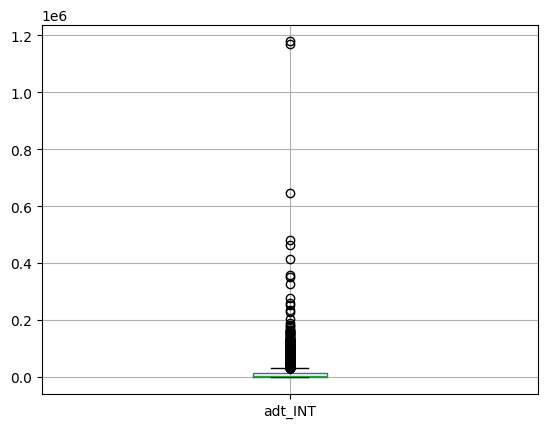

In [24]:
import matplotlib.pyplot as plt

df_ticker_aggs.boxplot(column='adt_INT')
plt.show()

In [25]:
from scipy.stats import iqr
import numpy as np


result = iqr(df_ticker_aggs['avg_daily_transactions'])

print(f"IQR: {result}")

IQR: 12303.126598766179


In [26]:
thresholds = [5000, 10000, 15000, 20000, 25000, 30000, 40000, 50000, 100000]

for t in thresholds:
    count = (df_ticker_aggs['adt_INT'] >= t).sum()
    print(f">={t}: {count}")

>=5000: 2746
>=10000: 1752
>=15000: 1187
>=20000: 859
>=25000: 666
>=30000: 523
>=40000: 353
>=50000: 243
>=100000: 71


In [27]:
combined_df_exp = pd.merge(df_metafb_fix, df_ticker_aggs, on='ticker')


df_stocks_30000_transacs = combined_df_exp[combined_df_exp['avg_daily_transactions'] >= 30000]
df_stocks_30000_transacs

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_daily_transactions,adt_INT
1254,2021-05-05,AA,39.37,40.880,38.640,40.60,7.773673e+06,40.1427,54715.0,57630.615630,57630
1255,2021-05-06,AA,40.89,41.440,39.280,39.89,7.308031e+06,40.0879,52580.0,57630.615630,57630
1256,2021-05-07,AA,39.76,41.380,39.250,41.20,4.909460e+06,40.6481,40057.0,57630.615630,57630
1257,2021-05-10,AA,42.75,44.420,41.020,41.04,1.183422e+07,42.5571,81210.0,57630.615630,57630
1258,2021-05-11,AA,39.07,42.150,38.960,41.32,9.246082e+06,40.8798,71792.0,57630.615630,57630
...,...,...,...,...,...,...,...,...,...,...,...
4979176,2026-04-27,ZTS,116.62,119.680,116.600,117.87,3.160355e+06,118.2275,43149.0,37895.856459,37895
4979177,2026-04-28,ZTS,117.23,118.290,116.075,116.65,2.972547e+06,117.0538,47388.0,37895.856459,37895
4979178,2026-04-29,ZTS,115.50,115.905,112.970,113.83,3.401808e+06,113.9745,47839.0,37895.856459,37895
4979179,2026-04-30,ZTS,114.04,115.535,113.790,114.97,4.297206e+06,114.7143,57409.0,37895.856459,37895


Now we should drop data with insufficient counts.

In [28]:
(df_stocks_30000_transacs['ticker'] == 'META').sum()

np.int64(1254)

In [29]:
df_stocks_30000_transacs['ticker'].value_counts()

ticker
AA      1254
PCG     1254
NEE     1254
NDAQ    1254
NCLH    1254
        ... 
XE         6
AVLN       2
COAG       1
UCFI       1
SPTX       1
Name: count, Length: 523, dtype: int64

In [31]:
df_ticker_counts = df_stocks_30000_transacs['ticker'].value_counts().reset_index()
df_ticker_counts.columns = ['ticker', 'count']
df_ticker_counts

,ticker,count
0,AA,1254
1,PCG,1254
2,NEE,1254
3,NDAQ,1254
4,NCLH,1254
...,...,...
518,XE,6
519,AVLN,2
520,COAG,1
521,UCFI,1


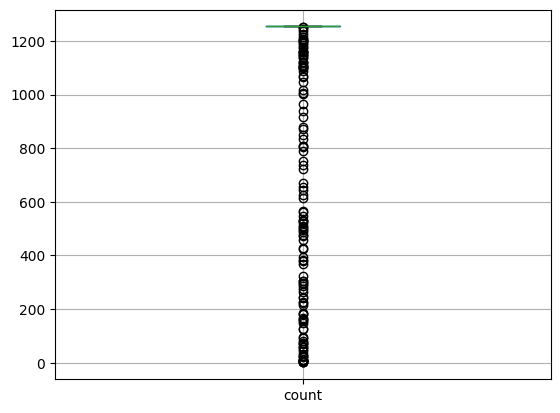

In [32]:
import matplotlib.pyplot as plt

df_ticker_counts.boxplot(column='count')
plt.show()

In [65]:
1254 * .02

25.080000000000002

In [69]:
thresholds = [1200, 1220, 1229, 1230, 1240, 1250, 1253, 1254]

for t in thresholds:
    count = (df_ticker_counts['count'] >= t).sum()
    print(f">={t}: {count}")

>=1200: 405
>=1220: 401
>=1229: 400
>=1230: 400
>=1240: 399
>=1250: 398
>=1253: 398
>=1254: 396


Drop tickers with insufficient counts. 

I will tolerate up to 2% of days missing, ONLY IF there are never any consecutive days missing.

In [53]:
df_30000_filt = df_stocks_30000_transacs.copy()


In [68]:
import pandas as pd

df = df_stocks_30000_transacs.copy()

def build_missing_days_df(
    df,
    ticker_col='ticker',
    date_col='timestamp',
    min_missing=1,
    max_missing=25
):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col]).dt.normalize()

    # Count unique dates per ticker
    ticker_day_counts = df.groupby(ticker_col)[date_col].nunique()

    # Tickers with the maximum observed date count
    max_day_count = ticker_day_counts.max()
    reference_tickers = ticker_day_counts[ticker_day_counts == max_day_count].index

    # Reference calendar = dates present for max-count tickers
    # Using union across max-count tickers
    reference_days = (
        df.loc[df[ticker_col].isin(reference_tickers), date_col]
        .drop_duplicates()
        .sort_values()
    )

    reference_days = pd.Index(reference_days)
    reference_day_count = len(reference_days)

    rows = []

    for ticker, df_ticker in df.groupby(ticker_col):
        ticker_days = pd.Index(df_ticker[date_col].drop_duplicates())
        missing_days = reference_days.difference(ticker_days).sort_values()

        missing_count = len(missing_days)

        if min_missing <= missing_count <= max_missing:
            rows.append({
                ticker_col: ticker,
                'missing_count': missing_count,
                'missing_days': list(missing_days),
                'missing_days_str': ', '.join(d.strftime('%Y-%m-%d') for d in missing_days)
            })

    missing_days_df = pd.DataFrame(rows).sort_values(
        by='missing_count',
        ascending=True
    ).reset_index(drop=True)

    print(f"Max observed day count: {max_day_count}")
    print(f"Reference ticker count: {len(reference_tickers)}")
    print(f"Reference calendar day count: {reference_day_count}")
    print(f"Tickers with {min_missing}-{max_missing} missing days: {len(missing_days_df)}")

    return missing_days_df


missing_1_to_25_df = build_missing_days_df(
    df_30000_filt,
    min_missing=1,
    max_missing=25
)

pd.set_option('display.max_colwidth', None)

missing_1_to_25_df

Max observed day count: 1254
Reference ticker count: 396
Reference calendar day count: 1254
Tickers with 1-25 missing days: 4


,ticker,missing_count,missing_days,missing_days_str
0,CLSK,1,[2024-11-08 00:00:00],2024-11-08
1,NVAX,1,[2022-06-07 00:00:00],2022-06-07
2,OWL,11,"[2021-05-05 00:00:00, 2021-05-06 00:00:00, 2021-05-07 00:00:00, 2021-05-10 00:00:00, 2021-05-11 00:00:00, 2021-05-12 00:00:00, 2021-05-13 00:00:00, 2021-05-14 00:00:00, 2021-05-17 00:00:00, 2021-05-18 00:00:00, 2021-05-19 00:00:00]","2021-05-05, 2021-05-06, 2021-05-07, 2021-05-10, 2021-05-11, 2021-05-12, 2021-05-13, 2021-05-14, 2021-05-17, 2021-05-18, 2021-05-19"
3,SOFI,18,"[2021-05-05 00:00:00, 2021-05-06 00:00:00, 2021-05-07 00:00:00, 2021-05-10 00:00:00, 2021-05-11 00:00:00, 2021-05-12 00:00:00, 2021-05-13 00:00:00, 2021-05-14 00:00:00, 2021-05-17 00:00:00, 2021-05-18 00:00:00, 2021-05-19 00:00:00, 2021-05-20 00:00:00, 2021-05-21 00:00:00, 2021-05-24 00:00:00, 2021-05-25 00:00:00, 2021-05-26 00:00:00, 2021-05-27 00:00:00, 2021-05-28 00:00:00]","2021-05-05, 2021-05-06, 2021-05-07, 2021-05-10, 2021-05-11, 2021-05-12, 2021-05-13, 2021-05-14, 2021-05-17, 2021-05-18, 2021-05-19, 2021-05-20, 2021-05-21, 2021-05-24, 2021-05-25, 2021-05-26, 2021-05-27, 2021-05-28"


In [70]:
pd.reset_option('display.max_colwidth', None)

Conditionally, I'll keep CLSK and NVAX, which each have a single null, as long as these do not fall on Monday or Friday, because I want to run some analysis on weekend changes.

OWL and SOFI have too many consecutive nulls, although the latter could be acceptable soon in the future as its nulls end May 29, 2021.

All others have too many nulls.

In [76]:
# What day of the week was CLSK missing?
print(datetime(2024, 11, 8).strftime('%A'))

Friday


In [77]:
# What day of the week was NVAX missing?
print(datetime(2022, 6, 7).strftime('%A'))

Tuesday


CLSK will be dropped. NSX will stay with values between the next and previous days.

First we will drop tickers with value_counts under 1253.

In [89]:
import pandas as pd

df = df_stocks_30000_transacs.copy()
df['timestamp'] = pd.to_datetime(df['timestamp']).dt.normalize()

# Count unique trading days per ticker
ticker_day_counts = df.groupby('ticker')['timestamp'].nunique()

# Keep tickers with at least 1253 days
valid_tickers = ticker_day_counts[ticker_day_counts >= 1253].index

# Filter dataframe
df_filtered = df[df['ticker'].isin(valid_tickers)].copy()

# Diagnostics
print(f"Total tickers before: {df['ticker'].nunique()}")
print(f"Total tickers after: {len(valid_tickers)}")
print(f"Min day count kept: {ticker_day_counts.loc[valid_tickers].min()}")
print(f"Max day count: {ticker_day_counts.max()}")

Total tickers before: 523
Total tickers after: 398
Min day count kept: 1253
Max day count: 1254


Only two stocks should have value_counts of 397, all others being 398.

In [92]:
df_filtered['ticker'].value_counts()

ticker
AA      1254
OPEN    1254
ON      1254
OMC     1254
OKTA    1254
        ... 
EA      1254
DXCM    1254
ZTS     1254
NVAX    1253
CLSK    1253
Name: count, Length: 398, dtype: int64

Drop CLSK.

In [94]:
df_filtered = df_filtered[df_filtered['ticker'] != 'CLSK']

In [95]:
df_filtered['ticker'].value_counts()

ticker
AA      1254
OPEN    1254
ON      1254
OMC     1254
OKTA    1254
        ... 
EBAY    1254
EA      1254
DXCM    1254
ZTS     1254
NVAX    1253
Name: count, Length: 397, dtype: int64

Now we will fill NVAX on June 7, 2022.

In [103]:
import pandas as pd

# --- SETTINGS ---
SOURCE_DF = df_filtered          # change if your dataframe has a different name
TICKER_TO_FIX = "NVAX"
REFERENCE_MIN_DAYS = 1254         # expected full count
DATE_COL = "timestamp"
TICKER_COL = "ticker"

# --- Make clean working copy ---
df = SOURCE_DF.copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL]).dt.normalize()

# --- Build reference calendar from tickers with the max observed day count ---
ticker_day_counts = df.groupby(TICKER_COL)[DATE_COL].nunique()
max_day_count = ticker_day_counts.max()

reference_tickers = ticker_day_counts[ticker_day_counts == max_day_count].index

reference_days = (
    df.loc[df[TICKER_COL].isin(reference_tickers), DATE_COL]
    .drop_duplicates()
    .sort_values()
)

reference_days = pd.Index(reference_days)

# --- Isolate ticker to fix ---
df_ticker = (
    df[df[TICKER_COL].eq(TICKER_TO_FIX)]
    .drop_duplicates(subset=[DATE_COL])
    .set_index(DATE_COL)
    .sort_index()
)

# --- Identify missing dates before filling ---
missing_days = reference_days.difference(df_ticker.index).sort_values()

print(f"Ticker being fixed: {TICKER_TO_FIX}")
print(f"Reference calendar days: {len(reference_days)}")
print(f"{TICKER_TO_FIX} current days: {len(df_ticker)}")
print(f"Missing days: {len(missing_days)}")
print([d.strftime("%Y-%m-%d") for d in missing_days])

# --- Reindex to insert missing row(s) ---
df_ticker_fixed = df_ticker.reindex(reference_days)

# --- Restore ticker value on inserted rows ---
df_ticker_fixed[TICKER_COL] = TICKER_TO_FIX

# --- Interpolate numeric columns ---
numeric_cols = df_ticker_fixed.select_dtypes(include="number").columns

df_ticker_fixed[numeric_cols] = (
    df_ticker_fixed[numeric_cols]
    .interpolate(method="linear")
)

# --- Reset index back to normal dataframe format ---
df_ticker_fixed = (
    df_ticker_fixed
    .reset_index()
    .rename(columns={"index": DATE_COL})
)

# --- Remove old ticker rows from original dataframe ---
df_without_ticker = df[~df[TICKER_COL].eq(TICKER_TO_FIX)].copy()

# --- Recombine fixed ticker with rest of dataframe ---
df_fixed = (
    pd.concat([df_without_ticker, df_ticker_fixed], ignore_index=True)
    .sort_values([TICKER_COL, DATE_COL])
    .reset_index(drop=True)
)

# --- Final diagnostics ---
new_count = df_fixed[df_fixed[TICKER_COL].eq(TICKER_TO_FIX)][DATE_COL].nunique()

print(f"\n{TICKER_TO_FIX} fixed day count: {new_count}")
print(f"Rows added: {new_count - len(df_ticker)}")

# Optional: view the inserted/fixed rows
df_fixed[
    (df_fixed[TICKER_COL].eq(TICKER_TO_FIX)) &
    (df_fixed[DATE_COL].isin(missing_days))
]

Ticker being fixed: NVAX
Reference calendar days: 1254
NVAX current days: 1253
Missing days: 1
['2022-06-07']

NVAX fixed day count: 1254
Rows added: 1


,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_daily_transactions,adt_INT
331331,2022-06-07,NVAX,48.81,50.78685,44.865,48.825,17290837.5,48.2421,168464.5,50638.595371,50638.0


In [104]:
df_fixed['ticker'].value_counts()

ticker
AA      1254
OPEN    1254
ON      1254
OMC     1254
OKTA    1254
        ... 
EL      1254
EBAY    1254
EA      1254
DXCM    1254
ZTS     1254
Name: count, Length: 397, dtype: int64

In [106]:
df_fixed['ticker'].nunique()

397

In [1]:
df_fixed.to_csv('transformed_daily_data/Daily Data 5 years 30k transacs.csv', index=False)

NameError: name 'df_fixed' is not defined

# Old Stuff Below

In [48]:
df_30000_filt['ticker'].nunique()

523

In [49]:
all_days = df_30000_filt['timestamp'].sort_values().unique()
total_days = len(all_days)  # should be ~1254
total_days

1254

# Volume adjusted?

In [8]:
combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv
...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv


# Adding day of week

In [7]:
# 1. Convert the 'date' column to datetime objects
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# 2. Add the 'day_of_week' column
combined_df['day_of_week'] = combined_df['timestamp'].dt.day_name()

combined_df

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday


# Manually calculated metrics

In [9]:
df_calculated_metrics = combined_df.copy()

df_calculated_metrics['close_vs_open'] = df_calculated_metrics['close'] - df_calculated_metrics['open']

df_calculated_metrics['daily_high_vs_low'] = (df_calculated_metrics['high'] - df_calculated_metrics['low'].abs())

df_calculated_metrics['close_vs_prev_day'] = df_calculated_metrics.groupby('ticker')['close'].diff()

df_calculated_metrics['open_vs_prev_close'] = (
    df_calculated_metrics['open'] 
    - df_calculated_metrics.groupby('ticker')['close'].shift(1)
)

df_calculated_metrics

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open,daily_high_vs_low,close_vs_prev_day,open_vs_prev_close
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday,1.420,2.38990,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.490,1.46000,-0.14,-0.630
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.540,1.61000,1.23,0.690
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday,-1.040,1.86500,-1.61,-0.570
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday,-0.730,1.72000,-0.63,0.100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday,-0.550,0.65000,-0.51,0.040
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday,-0.090,0.45000,-0.13,-0.040
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,0.310,0.71903,0.33,0.020
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday,-0.265,0.55500,-0.21,0.055


# Same as above but with pcts

In [10]:
def add_vs_group_average(
    df,
    value_col,
    group_col='timestamp',
    new_col_name=None
):
    """
    Adds a column showing deviation from group average.

    Parameters:
    - df: DataFrame
    - value_col: column to analyze (str)
    - group_col: column to group by (default: 'timestamp')
    - new_col_name: optional custom output column name

    Returns:
    - DataFrame with new column added
    """

    if new_col_name is None:
        new_col_name = f"{value_col}_VS_{group_col.upper()}_AVG"

    group_avg = df.groupby(group_col)[value_col].transform('mean')

    df[new_col_name] = df[value_col] - group_avg

    return df



df_calculated_metrics_pct = combined_df.copy()




# Close vs Open (% change from open → close)
df_calculated_metrics_pct['close_vs_open_pct'] = (
    (df_calculated_metrics_pct['close'] - df_calculated_metrics_pct['open']) 
    / df_calculated_metrics_pct['open']
) * 100


# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='close_vs_open_pct'
)





# Daily High vs Low (% range relative to low)
df_calculated_metrics_pct['daily_high_vs_low_pct'] = (
    (df_calculated_metrics_pct['high'] - df_calculated_metrics_pct['low']) 
    / df_calculated_metrics_pct['low']
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='daily_high_vs_low_pct'
)




# Close vs Previous Day (% change from prior close)
df_calculated_metrics_pct['close_vs_prev_day_pct'] = (
    df_calculated_metrics_pct.groupby('ticker')['close']
    .pct_change()
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='close_vs_prev_day_pct'
)




# Open vs Previous Close (% gap up/down)
df_calculated_metrics_pct['open_vs_prev_close_pct'] = (
    (df_calculated_metrics_pct['open'] - 
     df_calculated_metrics_pct.groupby('ticker')['close'].shift(1))
    / df_calculated_metrics_pct.groupby('ticker')['close'].shift(1)
) * 100

# VS DAILY AVG
df_calculated_metrics_pct = add_vs_group_average(
    df_calculated_metrics_pct,
    value_col='open_vs_prev_close_pct'
)




df_calculated_metrics_pct

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,Thursday,1.254306,1.263327,2.119457,-0.149662,NaN,NaN,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.429825,0.373002,1.286457,-0.450464,-0.122132,0.442339,-0.549594,0.069258
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.468831,0.345915,1.398419,-0.527532,1.074330,0.420341,0.602673,0.074314
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,Tuesday,-0.903170,-0.796573,1.642665,-0.790055,-1.391289,-0.883040,-0.492568,-0.089038
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,Wednesday,-0.639173,-0.494764,1.519972,-0.568881,-0.552099,-0.900662,0.087635,-0.406830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37645,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,Wednesday,-2.010969,-1.957297,2.430815,0.469993,-1.867448,-2.508766,0.146466,-0.545182
37646,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,Thursday,-0.336323,-0.326937,1.705838,-0.550905,-0.485075,-0.424326,-0.149254,-0.094533
37647,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,1.161484,1.039164,2.705154,0.726957,1.237345,1.132569,0.074991,0.094711
37648,2026-04-27,PFE,27.055,27.34500,26.790,26.79,3.476867e+07,26.9315,126925,273.930817,daily_pfe.csv,Monday,-0.979486,-1.223894,2.071669,0.085366,-0.777778,-0.795422,0.203704,0.429882


# Fridays and mondays Mondays only? To see what happened over the weekend.

In [16]:
df_mon_fri = df_calculated_metrics_pct[df_calculated_metrics_pct['day_of_week'].isin(['Monday', 'Friday'])]
df_mon_fri

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
1,2021-04-30,SBUX,114.000,114.95000,113.49,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,Friday,0.429825,0.373002,1.286457,-0.450464,-0.122132,0.442339,-0.549594,0.069258
2,2021-05-03,SBUX,115.180,116.74000,115.13,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,Monday,0.468831,0.345915,1.398419,-0.527532,1.074330,0.420341,0.602673,0.074314
6,2021-05-07,SBUX,115.110,115.84000,114.24,114.34,4.867501e+06,114.7774,73762,65.989276,daily_sbux.csv,Friday,-0.668925,-1.495380,1.400560,-0.595805,-0.348614,-1.193295,0.322468,0.296612
7,2021-05-10,SBUX,114.570,116.08500,114.21,114.30,5.759483e+06,115.0125,84445,68.203955,daily_sbux.csv,Monday,-0.235664,1.017525,1.641713,-0.612046,-0.034983,1.072635,0.201154,0.058580
11,2021-05-14,SBUX,111.010,111.59000,110.25,111.20,6.776260e+06,111.1482,74453,91.013928,daily_sbux.csv,Friday,0.171156,-0.600879,1.215420,-0.490209,0.642592,-0.985682,0.470631,-0.377006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37638,2026-04-13,PFE,26.830,27.57000,26.68,27.34,4.415430e+07,27.1787,151727,291.011474,daily_pfe.csv,Monday,1.900857,0.833213,3.335832,1.003300,1.560178,0.872305,-0.334324,0.037829
37642,2026-04-17,PFE,27.330,27.67000,27.12,27.56,3.008041e+07,27.4778,122853,244.848764,daily_pfe.csv,Friday,0.841566,0.180126,2.028024,-0.383241,1.249082,0.271040,0.404115,0.081790
37643,2026-04-20,PFE,27.585,27.84500,27.51,27.52,2.502303e+07,27.6351,106231,235.552987,daily_pfe.csv,Monday,-0.235635,-0.219870,1.217739,-0.747431,-0.145138,0.046318,0.090711,0.265353
37647,2026-04-24,PFE,26.690,27.29903,26.58,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,Friday,1.161484,1.039164,2.705154,0.726957,1.237345,1.132569,0.074991,0.094711


In [17]:
df_aapl_mon_fri = df_mon_fri[df_mon_fri['ticker'] == 'AAPL']
df_aapl_mon_fri

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,day_of_week,close_vs_open_pct,close_vs_open_pct_VS_TIMESTAMP_AVG,daily_high_vs_low_pct,daily_high_vs_low_pct_VS_TIMESTAMP_AVG,close_vs_prev_day_pct,close_vs_prev_day_pct_VS_TIMESTAMP_AVG,open_vs_prev_close_pct,open_vs_prev_close_pct_VS_TIMESTAMP_AVG
23846,2021-04-30,AAPL,131.780,133.5600,131.065,131.46,1.094255e+08,132.1940,701292,156.034100,daily_aapl.csv,Friday,-0.242829,-0.299652,1.903636,0.166714,-1.513335,-0.948864,-1.273599,-0.654747
23847,2021-05-03,AAPL,132.040,134.0700,131.830,132.54,7.513510e+07,132.8122,580631,129.402495,daily_aapl.csv,Monday,0.378673,0.255757,1.699158,-0.226794,0.821543,0.167554,0.441199,-0.087160
23851,2021-05-07,AAPL,130.850,131.2582,129.475,130.21,7.769127e+07,130.4433,545296,142.475413,daily_aapl.csv,Friday,-0.489110,-1.315565,1.377254,-0.619111,0.362263,-0.482418,0.855557,0.829701
23852,2021-05-10,AAPL,129.410,129.5400,126.810,126.85,8.807123e+07,127.8422,680681,129.386936,daily_aapl.csv,Monday,-1.978209,-0.725020,2.152827,-0.100931,-2.580447,-1.472828,-0.614392,-0.756967
23856,2021-05-14,AAPL,126.250,127.8900,125.850,127.45,8.187295e+07,126.9616,535527,152.882956,daily_aapl.csv,Friday,0.950495,0.178461,1.620977,-0.084651,1.984476,0.356202,1.024246,0.176609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25088,2026-04-13,AAPL,259.730,260.1800,256.660,259.20,3.623152e+07,258.3498,578488,62.631419,daily_aapl.csv,Monday,-0.204058,-1.271702,1.371464,-0.961068,-0.491400,-1.179274,-0.287930,0.084223
25092,2026-04-17,AAPL,266.960,272.3000,266.720,270.23,6.143623e+07,269.8735,723488,84.916720,daily_aapl.csv,Friday,1.224903,0.563462,2.092082,-0.319183,2.593014,1.614973,1.351557,1.029232
25093,2026-04-20,AAPL,270.330,274.2750,270.290,273.05,3.658260e+07,272.6888,541032,67.616332,daily_aapl.csv,Monday,1.006178,1.021943,1.474342,-0.490827,1.043555,1.235011,0.037006,0.211647
25097,2026-04-24,AAPL,272.755,273.0600,269.650,271.06,3.814749e+07,270.8897,593210,64.306890,daily_aapl.csv,Friday,-0.621437,-0.743756,1.264602,-0.713595,-0.866767,-0.971543,-0.246864,-0.227143


# Close_Vs_Open_Pct Agg

# SMAs

Dilemma - With a strict 20 day SMA, the first 20 days of the dataset will be dropped for lack of available data. And so on with larger spans.

I will make two versions - one with the strict limit that will result in some NaNs, and another that uses whatever data available.

In [11]:
df_sma_strict = combined_df.copy()
df_sma_loose = combined_df.copy()

df_sma_strict['close_SMA10'] = df_sma_strict['close'].rolling(window=10).mean()
df_sma_strict['close_SMA20'] = df_sma_strict['close'].rolling(window=20).mean()
df_sma_strict['close_SMA50'] = df_sma_strict['close'].rolling(window=50).mean()
df_sma_strict['close_SMA100'] = df_sma_strict['close'].rolling(window=100).mean()

df_sma_loose['close_SMA10'] = df_sma_loose['close'].rolling(window=10, min_periods=1).mean()
df_sma_loose['close_SMA20'] = df_sma_loose['close'].rolling(window=20, min_periods=1).mean()
df_sma_loose['close_SMA50'] = df_sma_loose['close'].rolling(window=50, min_periods=1).mean()
df_sma_loose['close_SMA100'] = df_sma_loose['close'].rolling(window=100, min_periods=1).mean()

In [12]:
df_sma_strict

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,close_SMA10,close_SMA20,close_SMA50,close_SMA100
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,NaN,NaN,NaN,NaN
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,NaN,NaN,NaN,NaN
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,NaN,NaN,NaN,NaN
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,NaN,NaN,NaN,NaN
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv,27.286,27.4680,27.2490,26.4443
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,27.219,27.4600,27.2440,26.4551
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,27.164,27.4295,27.2252,26.4647
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,27.172,27.4010,27.2106,26.4773


In [13]:
df_sma_loose

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,avg_volume_per_transac,source_file,close_SMA10,close_SMA20,close_SMA50,close_SMA100
0,2021-04-29,SBUX,113.210,115.14990,112.760,114.63,8.936555e+06,114.5165,115507,77.368082,daily_sbux.csv,114.630000,114.630000,114.630000,114.630000
1,2021-04-30,SBUX,114.000,114.95000,113.490,114.49,6.478714e+06,114.1842,75032,86.346012,daily_sbux.csv,114.560000,114.560000,114.560000,114.560000
2,2021-05-03,SBUX,115.180,116.74000,115.130,115.72,5.049806e+06,115.8671,67791,74.490803,daily_sbux.csv,114.946667,114.946667,114.946667,114.946667
3,2021-05-04,SBUX,115.150,115.40000,113.535,114.11,6.265098e+06,114.2311,85358,73.397901,daily_sbux.csv,114.737500,114.737500,114.737500,114.737500
4,2021-05-05,SBUX,114.210,114.88000,113.160,113.48,4.677689e+06,113.7666,68523,68.264510,daily_sbux.csv,114.486000,114.486000,114.486000,114.486000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37615,2026-04-21,PFE,27.520,27.62000,27.200,27.31,2.982883e+07,27.4023,136478,218.561453,daily_pfe.csv,27.286000,27.468000,27.249000,26.444300
37616,2026-04-22,PFE,27.350,27.39000,26.740,26.80,3.524679e+07,26.8773,155477,226.700979,daily_pfe.csv,27.219000,27.460000,27.244000,26.455100
37617,2026-04-23,PFE,26.760,26.83000,26.380,26.67,3.871841e+07,26.5511,163518,236.783761,daily_pfe.csv,27.164000,27.429500,27.225200,26.464700
37618,2026-04-24,PFE,26.690,27.29903,26.580,27.00,4.250021e+07,26.9385,168756,251.844159,daily_pfe.csv,27.172000,27.401000,27.210600,26.477300
